# 11 · The classifier shoot-out

All five candidates, one table, one winner — chosen on macro-F1 with AUC as tiebreak, and written to `cls_winner.json` for notebooks 12, 14 and 15.

---

> **Where this sits.** `00 setup` → stage 1 candidates `01 YOLO` · `02 SAM` · `03 Moondream` → `04 seg shoot-out` → `05 crop dataset` → stage 2 candidates `06 InceptionV3` · `07 MaxViT-tiny` · `08 ResNet50` · `09 MobileNet+SVM` · `10 QSVM` → `11 cls shoot-out` → `12 Grad-CAM` → `13 external set` → `14 end-to-end` → `15 gap`. Every stage reads the previous one's artefacts from `runs_two_stage/`, so this notebook runs on its own — it does **not** need the others to be open.

> **Needs first:** `06`–`10` (any subset that has been run)

### Bootstrap — environment, hardware profile, shared config

Identical in every notebook of this series. It detects where it is running
(**Colab/T4**, **IBEX/A100**, or local), turns on the right accelerations for that GPU, pins the
seed, and re-opens the shared `runs_two_stage/` folder so **any notebook can be run on its own** —
each stage reads the previous stage's artefacts from disk, not from memory.

**The A100 / T4 split is deliberate.** Only *throughput* knobs change with the GPU (batch size,
dataloader workers, AMP dtype, RAM caching, how many smears SAM pseudo-labels). *Capacity* knobs —
model size, image size, epochs — stay identical on both, so an A100 run and a T4 run remain
scientifically comparable. Every result file records the tier that produced it.

In [62]:
# ═════════════════════════════════════════════════════════════════════════════
#  SCD pipeline · shared bootstrap  (identical in every notebook of the series)
# ═════════════════════════════════════════════════════════════════════════════
import os, sys, re, glob, json, math, time, random, shutil, zipfile, warnings, subprocess


def _refresh_import_path():
    '''make what pip just installed visible to THIS interpreter, without a kernel restart.

    On managed images (Kaggle / Colab / IBEX) pip usually lands in the per-user site
    directory. If that directory did not exist when python started, site.py never put it
    on sys.path -- so a fresh install stays invisible until the kernel is restarted.
    Re-adding the install targets by hand is what removes the "restart and run all" step.
    '''
    import site, sysconfig, importlib
    cands = [sysconfig.get_path('purelib'), sysconfig.get_path('platlib')]
    for get in (site.getusersitepackages, site.getsitepackages):
        try:
            got = get()
            cands += [got] if isinstance(got, str) else list(got)
        except Exception:
            pass
    for d in cands:
        if d and os.path.isdir(d) and d not in sys.path:
            sys.path.append(d)                       # append: never shadow the image's own
            print('  + sys.path', d)
    importlib.invalidate_caches()
    sys.modules.pop('pkg_resources', None)           # its metadata cache is now stale


def _ensure(*pkgs):
    '''pip-install only what is genuinely missing -- IBEX compute nodes are often offline.

    No -U: these images pin a whole CUDA/numpy stack, and upgrading a transitive dep to
    satisfy a new package is how you break cudf/numba for the rest of the session.
    '''
    miss = [spec for mod, spec in pkgs if not _has(mod)]
    if not miss:
        return
    print('installing:', *miss)
    base = [sys.executable, '-m', 'pip', 'install', '-q']
    log = []
    for extra in ([], ['--user']):                   # plain first; --user if it stayed invisible
        r = subprocess.run(base + extra + list(miss), capture_output=True, text=True)
        log.append((extra, r.stdout, r.stderr))
        _refresh_import_path()
        miss = [spec for mod, spec in pkgs if not _has(mod)]
        if not miss:
            return
    for extra, out, err in log:                      # only reached when it truly failed
        print('--- pip', *extra, '---')
        print((out or '')[-1500:], (err or '')[-1500:], sep='')
    raise ImportError(
        'could not import after installing: ' + ', '.join(miss) +
        '\n  pip output is above. If it shows a successful install, restart the kernel'
        '\n  and re-run -- the packages are on disk but not on this process sys.path.'
        '\n  On an offline node, install them by hand first.')


def _has(mod):
    try:
        __import__(mod)
        return True
    except Exception:
        return False


# cv2 normally rides in with ultralytics, but an ultralytics that is already present
# (or a pip that could not reach the network) leaves no opencv behind -- ask for it.
_ensure(('cv2', 'opencv-python-headless'),
        ('ultralytics', 'ultralytics'), ('kagglehub', 'kagglehub'))

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── where are we? ────────────────────────────────────────────────────────────
if 'google.colab' in sys.modules:
    PLATFORM = 'colab'
elif os.environ.get('SLURM_JOB_ID') or os.path.isdir('/ibex'):
    PLATFORM = 'ibex'
else:
    PLATFORM = 'local'

# ── which GPU? ───────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEV = 'cuda'
    GPU = torch.cuda.get_device_name(0)
    CAP = torch.cuda.get_device_capability(0)
    VRAM = torch.cuda.get_device_properties(0).total_memory / 2 ** 30
else:
    DEV, GPU, CAP, VRAM = 'cpu', 'cpu', (0, 0), 0.0

TIER = 'a100' if (CAP[0] >= 8 and VRAM >= 30) else ('t4' if DEV == 'cuda' else 'cpu')

# bf16 has fp32's exponent range -> no GradScaler, no overflow. fp16 (T4) still needs the scaler.
AMP_DTYPE = torch.bfloat16 if CAP[0] >= 8 else torch.float16
USE_SCALER = (AMP_DTYPE == torch.float16) and DEV == 'cuda'

if CAP[0] >= 8:                      # Ampere+: ~2x on every fp32 matmul/conv, for free
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

# throughput knobs ONLY -- see the markdown above for why capacity knobs are not in here
PROFILE = {
    'a100': dict(workers=8, prefetch=4, cls_batch=64, sam_embed_batch=8, sam_box_batch=32,
                 yolo_cache='ram', sam_points_bulk=32, sam_qc_smears=30, md_batch=8,
                 sam_max={'cuba_full': 200, 'uganda_clean': 200, 'uganda_neg': 100}),
    't4':   dict(workers=2, prefetch=2, cls_batch=32, sam_embed_batch=2, sam_box_batch=8,
                 yolo_cache=False, sam_points_bulk=24, sam_qc_smears=20, md_batch=2,
                 sam_max={'cuba_full': 60, 'uganda_clean': 60, 'uganda_neg': 30}),
    'cpu':  dict(workers=0, prefetch=2, cls_batch=8, sam_embed_batch=1, sam_box_batch=4,
                 yolo_cache=False, sam_points_bulk=16, sam_qc_smears=4, md_batch=1,
                 sam_max={'cuba_full': 6, 'uganda_clean': 6, 'uganda_neg': 3}),
}[TIER]

CFG = {
    # --- where things live (env vars win, so an sbatch script can set them) -------------------
    'data_root':  os.environ.get('SCD_DATA_ROOT', ''),
    'runs_dir':   os.environ.get('SCD_RUNS_DIR', ''),
    'drive_hints': ['/content/drive/MyDrive/SRSI_Final',
                    '/content/drive/MyDrive/SRSI SCD project'],
    'local_hints': [os.path.join(os.getcwd(), 'data', 'Sickle_Cell_Dataset'),  # unzipped next to the notebooks
                    os.path.expanduser('~/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/Downloads/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/Desktop/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/Documents/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/scratch/Sickle_Cell_Dataset'),
                    f"/ibex/user/{os.environ.get('USER', '')}/Sickle_Cell_Dataset",
                    os.getcwd(), os.path.join(os.getcwd(), 'data'),
                    os.path.expanduser('~/scratch'), os.path.expanduser('~/data'),
                    # IBEX keeps real data off $HOME (small quota); these are the usual homes for
                    # it, and the /ibex/*/USER globs catch project allocations without hard-coding
                    # a project code. Cheap: only existing dirs survive the filter below.
                    f"/ibex/user/{os.environ.get('USER', '')}",
                    f"/ibex/scratch/user/{os.environ.get('USER', '')}",
                    f"/ibex/ai/home/{os.environ.get('USER', '')}",
                    *sorted(glob.glob(f"/ibex/*/{os.environ.get('USER', 'no-such-user')}")),
                    *sorted(glob.glob(f"/ibex/*/*/{os.environ.get('USER', 'no-such-user')}")),
                    # last resort -- broad sweeps, may pick up duplicate copies of the dataset
                    os.path.dirname(os.getcwd()),
                    os.path.expanduser('~/Downloads'), os.path.expanduser('~/Desktop'),
                    '/content'],

    # --- stage 1: segmentation (capacity knobs -- identical on A100 and T4) -------------------
    'yolo_weights': 'yolo11s-seg.pt',   # A100 upgrade: 'yolo11m-seg.pt' (then re-run 01 AND 04)
    'yolo_imgsz':   1024,               # auto-falls back to 640 on CUDA OOM
    'yolo_epochs':  100,
    'yolo_patience': 20,
    'sam_variant':  'vit_b',            # A100 upgrade: 'vit_h' (record it -- it changes the result)
    'sam_side':     1024,
    'sam_points_bench': 32,             # points_per_side used for the BENCHMARK (never tier-scaled)
    'sam_ft_epochs': 20,
    'sam_ft_lr':    1e-4,
    'seg_val_frac': 0.20,               # held-out SMEARS
    'eval_side':    1024,               # long side every segmenter is benchmarked at

    # --- moondream ----------------------------------------------------------------------------
    'md_model':     'vikhyatk/moondream2',
    'md_prompts':   ['red blood cell', 'blood cell', 'cell', 'erythrocyte', 'round red cell'],
    'md_finetune':  True,               # falls back to prompt-calibrated zero-shot, loudly

    # --- stage 2: classification (5 candidates, one shared trainer + one shared scorer) --------
    'epochs_head': 8,                   # phase 1 -- frozen backbone, new head only
    'epochs_ft': 12,                    # phase 2 -- top blocks unfrozen at 10x lower LR
    'lr_head': 1e-3,
    'lr_ft': 1e-4,
    'cuba_block': 10,                   # Cuba crops carry no smear ID -> contiguous ID blocks
    'val_frac': 0.15,
    'test_frac': 0.15,

    # --- the two shallow candidates -----------------------------------------------------------
    'svm_C_grid': [0.1, 1.0, 10.0, 100.0],
    'svm_gamma_grid': ['scale', 0.01, 0.001],
    'qsvm_qubits': 8,                   # = PCA components; statevector is 2**this
    'qsvm_reps': 2,                     # ZZFeatureMap repetitions
    'qsvm_max_train': 4000,             # caps the N x N kernel; -1 = no cap
    'qsvm_bandwidth_grid': [1.0, 0.5, 0.25, 0.125, 0.0625],   # THE knob -- see notebook 10

    # --- stage 3: the unseen external test set ------------------------------------------------
    'external_kaggle_id': '',
    'external_candidates': ['alitaqishah/blood-cell-anomaly-detection-2025',
                            'fenicxs/sickle-cell-anaemia'],
    'external_zenodo': '7801430',
    'external_max_mb': 500,

    'classes': ['circular', 'elongated'],   # 0 = circular (normal), 1 = elongated (sickle)
    **PROFILE,
}

CFG['batch'] = CFG['cls_batch']

# ── output root: survives a Colab reconnect, lives on scratch under SLURM ─────
_drive = next((h for h in CFG['drive_hints'] if os.path.isdir(h)), '')
if not CFG['runs_dir']:
    CFG['runs_dir'] = os.path.join(_drive or os.getcwd(), 'runs_two_stage')

FIG = os.path.join(CFG['runs_dir'], 'figures')
WTS = os.path.join(CFG['runs_dir'], 'weights')
TAB = os.path.join(CFG['runs_dir'], 'tables')
BENCH = os.path.join(CFG['runs_dir'], 'seg_bench')     # stage-1 shoot-out results
CBENCH = os.path.join(CFG['runs_dir'], 'cls_bench')    # stage-2 shoot-out results
FEAT = os.path.join(CFG['runs_dir'], 'features')       # cached frozen-backbone embeddings
for _d in (FIG, WTS, TAB, BENCH, CBENCH, FEAT):
    os.makedirs(_d, exist_ok=True)

STATE_PATH = os.path.join(CFG['runs_dir'], 'state.json')


def read_state():
    '''everything earlier notebooks resolved (paths, split, measured constants)'''
    if os.path.exists(STATE_PATH):
        return json.load(open(STATE_PATH))
    return {}


def save_state(**kw):
    st = read_state()
    st.update(kw)
    json.dump(st, open(STATE_PATH, 'w'), indent=2, default=str)
    return st


def need(*keys, nb='00_setup_and_data.ipynb'):
    '''fetch values produced by an earlier notebook, with an error that says which one'''
    st = read_state()
    miss = [k for k in keys if k not in st]
    if miss:
        raise RuntimeError(f'missing {miss} in {STATE_PATH}\n  -> run {nb} first (it writes them)')
    out = [st[k] for k in keys]
    return out[0] if len(out) == 1 else out


CLR = {'circular': '#2E86C1', 'elongated': '#C0392B'}
SPLIT = {'internal': '#4C72B0', 'external': '#DD8452'}
METHOD_CLR = {'yolo11-seg': '#2E86C1', 'sam-zeroshot': '#95A5A6',
              'sam-finetuned': '#27AE60', 'moondream': '#8E44AD',
              'inceptionv3': '#2E86C1', 'maxvit_tiny': '#8E44AD', 'resnet50': '#E67E22',
              'mobilenet_svm': '#27AE60', 'qsvm_zz': '#C0392B', 'svm_rbf_pca': '#95A5A6'}
sns.set_theme(style='whitegrid', font_scale=0.95)

print(f'platform   {PLATFORM}' + (f"  | SLURM job {os.environ['SLURM_JOB_ID']}"
                                  if os.environ.get('SLURM_JOB_ID') else ''))
print(f'device     {GPU} | {VRAM:.0f} GB | sm_{CAP[0]}{CAP[1]}  ->  tier {TIER!r}, AMP {AMP_DTYPE}')
print(f'torch      {torch.__version__} | torchvision {torchvision.__version__} | cv2 {cv2.__version__}')
print(f'runs_dir   {CFG["runs_dir"]}')
if DEV == 'cpu':
    print('!! NO GPU -- Colab: Runtime > Change runtime type > T4.  IBEX: srun --gres=gpu:a100:1')

platform   ibex  | SLURM job 49919771
device     NVIDIA A100-SXM4-80GB | 79 GB | sm_80  ->  tier 'a100', AMP torch.bfloat16
torch      2.1.2 | torchvision 0.16.2 | cv2 4.11.0
runs_dir   /home/bahajao/runs_two_stage


In [63]:
# ── small utilities shared by every stage ────────────────────────────────────
IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')     # dataset has mixed-case .JPG


def imgs_in(d):
    '''image files sitting directly inside d (skips macOS ._ stubs)'''
    if not d or not os.path.isdir(d):
        return []
    return [os.path.join(d, f) for f in sorted(os.listdir(d))
            if f.lower().endswith(IMG_EXT) and not f.startswith('._')]


def load_rgb(path, long_side=None):
    im = cv2.imread(path)
    if im is None:
        raise FileNotFoundError(path)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    if long_side:
        s = long_side / max(im.shape[:2])
        if s < 1:
            im = cv2.resize(im, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
    return im


def savefig(fig, name):
    p = os.path.join(FIG, name)
    fig.savefig(p, dpi=150, bbox_inches='tight')
    return p


def mask_to_polys(mask, min_area=25):
    '''binary mask -> list of NORMALISED YOLO polygons [x1,y1,x2,y2,...]'''
    H, W = mask.shape
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polys = []
    for c in cnts:
        if cv2.contourArea(c) < min_area:
            continue
        c = cv2.approxPolyDP(c, 0.004 * cv2.arcLength(c, True), True)
        if len(c) < 3:
            continue
        p = c.reshape(-1, 2).astype(np.float32)
        p[:, 0] /= W
        p[:, 1] /= H
        polys.append(np.clip(p, 0, 1).reshape(-1))
    return polys


def read_polys(label_txt, W, H):
    '''YOLO-seg label file -> list of per-instance pixel polygons at (W, H)'''
    out = []
    for line in open(label_txt):
        v = line.split()[1:]
        if len(v) < 6:
            continue
        out.append((np.array(v, np.float32).reshape(-1, 2) * [W, H]).astype(np.int32))
    return out


def autocast_ctx():
    return torch.autocast('cuda', dtype=AMP_DTYPE, enabled=(DEV == 'cuda'))


def make_scaler():
    '''fp16 (T4) needs loss scaling; bf16 (A100) does not. torch>=2.4 moved the class.'''
    try:
        return torch.amp.GradScaler('cuda', enabled=USE_SCALER)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=USE_SCALER)


def free_gpu(*names):
    '''free_gpu('sam', 'amg') -- drops the notebook globals, then empties the cache'''
    import gc
    for n in names:
        globals().pop(n, None)
    gc.collect()
    if DEV == 'cuda':
        torch.cuda.empty_cache()

### The shared stage-2 machinery

Five very different classifiers are compared here, so the comparison is only worth anything if
everything *except the model* is held fixed. This cell is that fixed part, and it is byte-identical
in notebooks 06–11:

* **one preprocessing path** — `TF_EVAL(size)`. Every crop the project ever classifies (internal,
  external, or handed over by the segmenter at inference) goes through it. Each backbone declares
  its own native input size; nothing else about the pipeline changes.
* **one trainer** — `train_deep()`. InceptionV3, MaxViT-tiny and ResNet50 are trained by the *same*
  two-phase loop, same optimiser, same class weights, same model selection on val macro-F1. Any
  difference in their scores is the architecture, not the training recipe.
* **one feature extractor** — `extract_features()`, cached to disk, so MobileNet+SVM and QSVM read
  identical embeddings instead of each computing their own.
* **one scorer** — `cls_benchmark()`, on the same internal held-out test split, writing one JSON per
  candidate into `cls_bench/`.

In [64]:
# ═════════════════════════════════════════════════════════════════════════════
#  SHARED STAGE-2 MACHINERY -- byte-identical in notebooks 06-11
# ═════════════════════════════════════════════════════════════════════════════
import torchvision.models as tvm
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, f1_score,
                             precision_recall_fscore_support, roc_curve, auc,
                             precision_recall_curve, average_precision_score)

NORM = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])


def TF_EVAL(size):
    return transforms.Compose([transforms.ToTensor(),
                               transforms.Resize((size, size), antialias=True), NORM])


def TF_TRAIN(size):
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((size, size), antialias=True),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20),
        transforms.RandomResizedCrop(size, scale=(0.8, 1.0), antialias=True),
        NORM])


# each backbone: native input size, which params are the "head", which blocks phase 2 unfreezes,
# and the layer Grad-CAM should look at.
BACKBONES = {
    'inceptionv3': dict(size=299, head=('fc', 'AuxLogits.fc'),
                        unfreeze=('Mixed_6', 'Mixed_7', 'fc', 'AuxLogits'), cam='Mixed_7c'),
    'maxvit_tiny': dict(size=224, head=('classifier',),
                        unfreeze=('blocks.2', 'blocks.3', 'classifier'), cam='blocks'),
    'resnet50':    dict(size=224, head=('fc',),
                        unfreeze=('layer3', 'layer4', 'fc'), cam='layer4'),
    'mobilenetv3': dict(size=224, head=('classifier',),
                        unfreeze=('features.14', 'features.15', 'features.16', 'classifier'),
                        cam='features'),
}


def build_backbone(name, headless=False):
    '''ImageNet-pretrained backbone with a 2-class head (or no head, for feature extraction)'''
    if name == 'inceptionv3':
        m = tvm.inception_v3(weights=tvm.Inception_V3_Weights.IMAGENET1K_V1)
        m.fc = nn.Identity() if headless else nn.Linear(m.fc.in_features, 2)
        if not headless:                                   # inception has TWO heads
            m.AuxLogits.fc = nn.Linear(m.AuxLogits.fc.in_features, 2)
    elif name == 'maxvit_tiny':
        m = tvm.maxvit_t(weights=tvm.MaxVit_T_Weights.IMAGENET1K_V1)
        m.classifier[-1] = nn.Identity() if headless else \
            nn.Linear(m.classifier[-1].in_features, 2)
    elif name == 'resnet50':
        m = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V2)
        m.fc = nn.Identity() if headless else nn.Linear(m.fc.in_features, 2)
    elif name == 'mobilenetv3':
        m = tvm.mobilenet_v3_large(weights=tvm.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
        m.classifier[-1] = nn.Identity() if headless else \
            nn.Linear(m.classifier[-1].in_features, 2)
    else:
        raise ValueError(f'unknown backbone {name!r} -- one of {list(BACKBONES)}')
    return m.to(DEV, memory_format=torch.channels_last)


class CropDS(Dataset):
    def __init__(self, df, tf):
        self.df = df.reset_index(drop=True)
        self.tf = tf

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        return self.tf(load_rgb(r.path)), int(r.y)


def loader(df, tf, shuffle=False, bs=None):
    '''pinned + persistent workers on A100, plain on T4/CPU'''
    kw = dict(batch_size=bs or CFG['cls_batch'], shuffle=shuffle, num_workers=CFG['workers'],
              pin_memory=(DEV == 'cuda'), drop_last=False)
    if CFG['workers'] > 0:
        kw.update(persistent_workers=True, prefetch_factor=CFG['prefetch'])
    return DataLoader(CropDS(df, tf), **kw)


@torch.no_grad()
def predict(model, dl):
    model.eval()
    P, Y = [], []
    for xb, yb in dl:
        xb = xb.to(DEV, memory_format=torch.channels_last, non_blocking=True)
        with autocast_ctx():
            out = model(xb)
        P.append(torch.softmax(out.float(), 1).cpu())
        Y.append(yb)
    return torch.cat(P).numpy(), torch.cat(Y).numpy()


# ── the ONE metric suite: internal, external and every candidate go through it ──
def full_eval(y, prob, name, colour='#4C72B0', pred=None, quiet=False):
    p1 = prob[:, 1]
    pred = prob.argmax(1) if pred is None else np.asarray(pred)
    pr, rc, f1, sup = precision_recall_fscore_support(y, pred, labels=[0, 1], zero_division=0)
    rep = pd.DataFrame({'precision': pr, 'recall': rc, 'f1': f1, 'support': sup},
                       index=CFG['classes'])
    macro = f1_score(y, pred, average='macro')
    accu = float((pred == y).mean())
    both = len(np.unique(y)) == 2
    A = AP = float('nan')
    if both:
        fpr, tpr, _ = roc_curve(y, p1)
        A, AP = auc(fpr, tpr), average_precision_score(y, p1)

    if not quiet:
        fig, ax = plt.subplots(1, 5, figsize=(25, 4.4))
        cm = confusion_matrix(y, pred, labels=[0, 1])
        ConfusionMatrixDisplay(cm, display_labels=CFG['classes']).plot(ax=ax[0], cmap='Blues',
                                                                      colorbar=False)
        ax[0].set_title(f'(a) confusion — counts\nacc={accu:.3f}')
        ConfusionMatrixDisplay(cm / np.maximum(cm.sum(1, keepdims=True), 1),
                               display_labels=CFG['classes']).plot(
            ax=ax[1], cmap='Blues', colorbar=False, values_format='.2f')
        ax[1].set_title('(b) confusion — row-normalised')
        if both:
            ax[2].plot(fpr, tpr, color=colour, label=f'AUC={A:.3f}')
            ax[2].plot([0, 1], [0, 1], '--', c='grey', lw=1)
            ax[2].legend()
            p_, r_, _ = precision_recall_curve(y, p1)
            ax[3].plot(r_, p_, color=colour, label=f'AP={AP:.3f}')
            ax[3].axhline(y.mean(), ls='--', c='grey', lw=1)
            ax[3].legend()
        else:
            for a in ax[2:4]:
                a.text(0.5, 0.5, 'single class present\n— ROC/PR undefined', ha='center')
        ax[2].set_title('(c) ROC')
        ax[2].set_xlabel('FPR')
        ax[2].set_ylabel('TPR')
        ax[3].set_title('(d) precision-recall')
        ax[3].set_xlabel('recall')
        ax[3].set_ylabel('precision')
        ax[4].bar(CFG['classes'], f1, color=[CLR['circular'], CLR['elongated']])
        ax[4].axhline(macro, ls='--', c='k', lw=1, label=f'macro-F1={macro:.3f}')
        ax[4].set_ylim(0, 1)
        ax[4].set_title('(e) per-class F1')
        ax[4].legend()
        slug = name.lower().replace(' ', '_').replace('-', '_')
        fig.suptitle(f'{name}  (n={len(y)})', y=1.04)
        savefig(fig, f'cls_{slug}.png')
        plt.show()
        print(f'\n=== {name} ===')
        print(rep.round(4).to_string())
        print(f'accuracy {accu:.4f} | macro-F1 {macro:.4f} | AUC {A:.4f} | AP {AP:.4f}')
        rep.to_csv(os.path.join(TAB, f'report_{slug}.csv'))
    return {'name': name, 'n': len(y), 'accuracy': accu, 'macro_f1': macro, 'auc': A, 'ap': AP,
            'f1_circular': f1[0], 'f1_elongated': f1[1],
            'recall_circular': rc[0], 'recall_elongated': rc[1]}


# ── the ONE stage-2 scorer: writes cls_bench/<method>.json ──
def cls_benchmark(method, y, prob, notes='', extra=None, colour=None):
    res = full_eval(y, prob, method, colour or METHOD_CLR.get(method, '#4C72B0'))
    res.update({'method': method, 'notes': notes, 'tier': TIER, 'gpu': GPU,
                'timestamp': time.strftime('%Y-%m-%d %H:%M')})
    res.update(extra or {})
    json.dump(res, open(os.path.join(CBENCH, f'{method}.json'), 'w'), indent=2, default=float)
    print(f'-> {os.path.join(CBENCH, method)}.json')
    return res


# ── the ONE deep-training loop: three architectures, identical recipe ──
def train_deep(name, colour=None):
    spec = BACKBONES[name]
    size = spec['size']
    ckpt = os.path.join(WTS, f'cls_{name}.pt')
    hist_p = os.path.join(TAB, f'cls_{name}_history.json')
    HK = ['train_loss', 'train_acc', 'val_loss', 'val_acc', 'val_f1']

    cnt = np.bincount(sub('train').y, minlength=2)
    CLS_W = torch.tensor(len(sub('train')) / (2 * np.maximum(cnt, 1)),
                         dtype=torch.float32, device=DEV)

    def phase(model, params, lr, epochs, hist, tag, dls):
        train_dl, val_dl = dls
        opt = torch.optim.Adam(params, lr=lr)
        scaler = make_scaler()
        crit = nn.CrossEntropyLoss(weight=CLS_W)
        best = hist.get('best_f1', -1)
        for ep in range(epochs):
            model.train()
            tl = tc = tn = 0
            for xb, yb in train_dl:
                xb = xb.to(DEV, memory_format=torch.channels_last, non_blocking=True)
                yb = yb.to(DEV, non_blocking=True)
                opt.zero_grad(set_to_none=True)
                with autocast_ctx():
                    out = model(xb)
                    if hasattr(out, 'logits'):            # inception's aux head, train mode only
                        logits = out.logits
                        loss = crit(logits, yb) + 0.4 * crit(out.aux_logits, yb)
                    else:
                        logits = out
                        loss = crit(logits, yb)
                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
                tl += loss.item() * len(yb)
                tc += (logits.argmax(1) == yb).sum().item()
                tn += len(yb)
            pv, yv = predict(model, val_dl)
            acc = float((pv.argmax(1) == yv).mean())
            f1 = f1_score(yv, pv.argmax(1), average='macro')
            w = CLS_W.cpu().numpy()[yv]                   # same weighting as the training loss
            vl = float(-(np.log(pv[np.arange(len(yv)), yv] + 1e-9) * w).sum() / w.sum())
            for k, v in zip(HK, [tl / tn, tc / tn, vl, acc, f1]):
                hist[k].append(v)
            if f1 > best:
                best = f1
                torch.save(model.state_dict(), ckpt)
            print(f'  {name} {tag} ep{ep + 1:02d}  loss {tl / tn:.4f} acc {tc / tn:.4f} '
                  f'| val loss {vl:.4f} acc {acc:.4f} macroF1 {f1:.4f}')
        hist['best_f1'] = best
        return hist

    def run(bs):
        dls = (loader(sub('train'), TF_TRAIN(size), shuffle=True, bs=bs),
               loader(sub('val'), TF_EVAL(size), bs=bs))
        m = build_backbone(name)
        h = {k: [] for k in HK}
        for p in m.parameters():                          # phase 1: heads only
            p.requires_grad = False
        head = [p for n_, p in m.named_parameters() if n_.startswith(spec['head'])]
        for p in head:
            p.requires_grad = True
        h = phase(m, head, CFG['lr_head'], CFG['epochs_head'], h, 'P1-head', dls)
        h['phase_switch'] = len(h['train_loss'])
        for n_, p in m.named_parameters():                # phase 2: top blocks
            if n_.startswith(spec['unfreeze']):
                p.requires_grad = True
        h = phase(m, [p for p in m.parameters() if p.requires_grad],
                  CFG['lr_ft'], CFG['epochs_ft'], h, 'P2-ft  ', dls)
        return m, h

    model = build_backbone(name)
    if os.path.exists(ckpt):
        model.load_state_dict(torch.load(ckpt, map_location=DEV))      # <- rerun-safe
        hist = json.load(open(hist_p)) if os.path.exists(hist_p) else {k: [] for k in HK}
        print(f'loaded trained {name} ->', ckpt)
    else:
        t0 = time.time()
        try:
            model, hist = run(CFG['cls_batch'])
        except torch.cuda.OutOfMemoryError:
            torch.cuda.empty_cache()
            print(f'!! CUDA OOM at batch {CFG["cls_batch"]} -- retrying at {CFG["cls_batch"] // 2}')
            model, hist = run(max(CFG['cls_batch'] // 2, 4))
        hist['minutes'] = (time.time() - t0) / 60
        hist['tier'] = TIER
        json.dump(hist, open(hist_p, 'w'))
        print(f'{name} trained in {hist["minutes"]:.1f} min on {GPU}')
        model.load_state_dict(torch.load(ckpt, map_location=DEV))
    model.eval()

    if hist['train_loss']:
        fig, ax = plt.subplots(1, 3, figsize=(16, 4))
        ax[0].plot(hist['train_loss'], label='train')
        ax[0].plot(hist['val_loss'], label='val')
        ax[1].plot(hist['train_acc'], label='train')
        ax[1].plot(hist['val_acc'], label='val')
        ax[2].plot(hist['val_f1'], color=colour or '#8E44AD', label='val macro-F1')
        for a, t in zip(ax, ['(a) loss', '(b) accuracy', '(c) val macro-F1 (model selection)']):
            a.set_title(t)
            a.set_xlabel('epoch')
            a.legend(fontsize=8)
            if 'phase_switch' in hist:
                a.axvline(hist['phase_switch'] - 0.5, ls='--', c='grey', lw=1)
        fig.suptitle(f'{name} two-phase fine-tuning (dashed = freeze → unfreeze)', y=1.03)
        savefig(fig, f'cls_{name}_curves.png')
        plt.show()
    return model, hist, ckpt


# ── frozen-backbone embeddings, cached so SVM and QSVM read identical features ──
@torch.no_grad()
def extract_features(name, split):
    f = os.path.join(FEAT, f'{name}_{split}.npz')
    if os.path.exists(f):                                              # <- rerun-safe
        d = np.load(f)
        return d['X'], d['y']
    m = build_backbone(name, headless=True).eval()
    dl = loader(sub(split), TF_EVAL(BACKBONES[name]['size']))
    X, Y = [], []
    for xb, yb in dl:
        xb = xb.to(DEV, memory_format=torch.channels_last, non_blocking=True)
        with autocast_ctx():
            X.append(m(xb).float().cpu().numpy())
        Y.append(yb.numpy())
    X, Y = np.concatenate(X), np.concatenate(Y)
    np.savez_compressed(f, X=X, y=Y)
    free_gpu()
    print(f'  {name} {split}: {X.shape} -> {f}')
    return X, Y


# ── quantum-kernel helpers: used by notebook 10, and by build_classifier if QSVM wins ────
#    Exact simulation of qiskit's ZZFeatureMap fidelity kernel. Per repetition the map is
#    H^(x)n followed by the diagonal unitary whose phase on basis state |b> is
#        sum_i 2*x_i*b_i  +  sum_{i<j} 2*(pi-x_i)*(pi-x_j)*(b_i XOR b_j)
#    so a fast Walsh-Hadamard transform plus a phase multiply reproduces it to machine
#    precision -- O(N) statevectors instead of O(N^2) circuit executions.
QNQ, QREPS = CFG['qsvm_qubits'], CFG['qsvm_reps']
QDIM = 1 << QNQ
_QBITS = ((np.arange(QDIM)[:, None] >> np.arange(QNQ)[None, :]) & 1).astype(np.float64)
_QPAIRS = [(i, j) for i in range(QNQ) for j in range(i + 1, QNQ)]
_QXOR = np.stack([np.logical_xor(_QBITS[:, i], _QBITS[:, j]) for i, j in _QPAIRS],
                 1).astype(np.float64)


def hadamard_all(psi):
    '''H^(x)n on a batch of statevectors -- fast Walsh-Hadamard, exact'''
    v = psi.copy()
    h = 1
    while h < QDIM:
        v = v.reshape(v.shape[0], -1, 2 * h)
        a = v[:, :, :h].copy()
        b = v[:, :, h:].copy()
        v[:, :, :h] = a + b
        v[:, :, h:] = a - b
        v = v.reshape(v.shape[0], QDIM)
        h *= 2
    return v / (2 ** (QNQ / 2))


def zz_statevectors(X):
    '''|phi(x)> for ZZFeatureMap(reps=QREPS, entanglement="full"), simulated exactly'''
    X = np.asarray(X, np.float64)
    P = np.stack([(np.pi - X[:, i]) * (np.pi - X[:, j]) for i, j in _QPAIRS], 1)
    phase = 2.0 * (X @ _QBITS.T) + 2.0 * (P @ _QXOR.T)                     # (N, QDIM)
    psi = np.full((len(X), QDIM), 1.0 / np.sqrt(QDIM), dtype=np.complex128)  # = H^(x)n |0..0>
    psi *= np.exp(1j * phase)
    for _ in range(QREPS - 1):
        psi = hadamard_all(psi)
        psi *= np.exp(1j * phase)
    return psi


def fidelity_kernel(Pa, Pb):
    '''K[i,j] = |<phi(a_i)|phi(b_j)>|^2 -- one matmul instead of N*M circuit runs'''
    return np.abs(Pa.conj() @ Pb.T) ** 2

## Which classifier wins?

Same story as the segmentation shoot-out in notebook 04: every row below came out of the same
scorer, on the same held-out test crops, from the same smear-grouped split. The winner is chosen on
**macro-F1** — not accuracy, which the majority `elongated` class would flatter — with AUC as the
tiebreak.

The families are not directly comparable on cost, so cost is reported instead of hidden: the deep
models pay GPU minutes to train and milliseconds to infer; the SVM pays nothing on a GPU; the QSVM
pays a kernel simulation. And `svm_rbf_pca` is the QSVM's control, marked as such.

The chosen model is written to `cls_bench/cls_winner.json`, and notebooks 12, 14 and 15 pick it up
from there.

In [65]:
files = [f for f in sorted(glob.glob(os.path.join(CBENCH, '*.json')))
         if os.path.basename(f) != 'cls_winner.json']
assert files, f'no results in {CBENCH} -- run notebooks 06-10 first'
runs = [json.load(open(f)) for f in files]
print('found:', ', '.join(r['method'] for r in runs))

COLS = ['method', 'family', 'macro_f1', 'accuracy', 'auc', 'ap', 'f1_circular', 'f1_elongated',
        'recall_circular', 'recall_elongated', 'input_size', 'ms_per_crop', 'train_minutes',
        'tier', 'notes']
comp = pd.DataFrame(runs).reindex(columns=COLS + ['is_control'])
comp['is_control'] = comp['is_control'].fillna(False).astype(bool)
comp = comp.sort_values('macro_f1', ascending=False).reset_index(drop=True)
comp.to_csv(os.path.join(TAB, 'classifier_comparison.csv'), index=False)

print('\n' + '=' * 118)
print(comp[COLS].drop(columns=['notes']).round(4).to_string(index=False))
print('=' * 118)
for r in runs:
    print(f"  {r['method']:16s} {r.get('notes', '')}")

found: inceptionv3, maxvit_tiny, mobilenet_svm, qsvm_zz, resnet50, svm_rbf_pca

       method                             family  macro_f1  accuracy   auc     ap  f1_circular  f1_elongated  recall_circular  recall_elongated  input_size  ms_per_crop  train_minutes tier
  inceptionv3                     deep fine-tune    1.0000    1.0000 1.000 1.0000       1.0000        1.0000           1.0000            1.0000         299       9.6533         0.7370 a100
     resnet50                     deep fine-tune    1.0000    1.0000 1.000 1.0000       1.0000        1.0000           1.0000            1.0000         224       2.1620         0.5037 a100
  maxvit_tiny                     deep fine-tune    0.9817    0.9922 1.000 1.0000       0.9677        0.9956           1.0000            0.9912         224      11.2506         1.0134 a100
mobilenet_svm frozen features + classical kernel    0.9817    0.9922 1.000 1.0000       0.9677        0.9956           1.0000            0.9912         224       0.

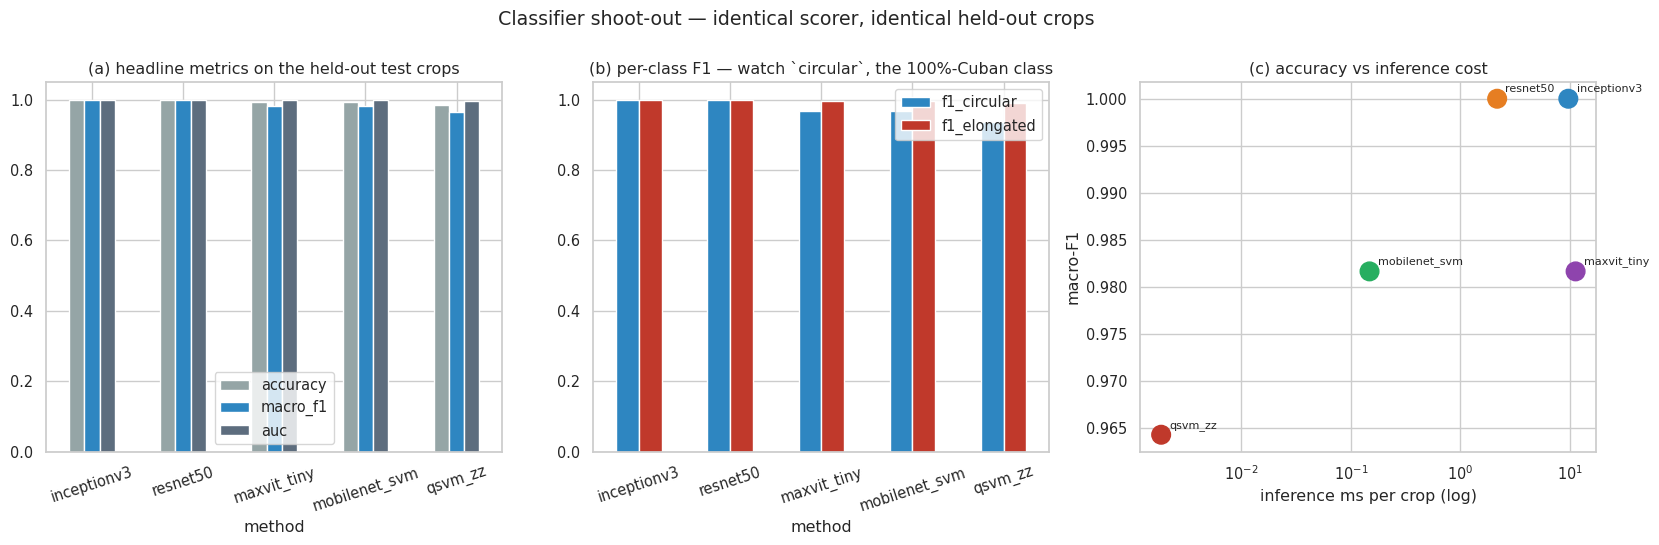

  WINNER: inceptionv3   macro-F1 1.0000 | acc 1.0000 | AUC 1.0000
  runner-up: resnet50  macro-F1 1.0000 (+0.0000)
  ranking : inceptionv3 > resnet50 > maxvit_tiny > mobilenet_svm > qsvm_zz
  spread across all 5 candidates: 0.0357 macro-F1
  -> A real architecture gap. Check (b): if it is `circular` F1 that separates them,
     the difference is in how much each model leans on the Cuba-only-healthy shortcut.
  !! qsvm_zz: noiseless statevector simulation -- not a hardware result


In [66]:
race = comp[~comp.is_control].reset_index(drop=True)
order = race.sort_values(['macro_f1', 'auc'], ascending=False)
WINNER = order.iloc[0].method
cols = [METHOD_CLR.get(m, '#7F8C8D') for m in race.method]

fig, ax = plt.subplots(1, 3, figsize=(20, 4.8))
race.set_index('method')[['accuracy', 'macro_f1', 'auc']].plot(
    kind='bar', ax=ax[0], color=['#95A5A6', '#2E86C1', '#5D6D7E'])
ax[0].set_ylim(0, 1.05)
ax[0].set_title('(a) headline metrics on the held-out test crops')
ax[0].tick_params(axis='x', rotation=18)

race.set_index('method')[['f1_circular', 'f1_elongated']].plot(
    kind='bar', ax=ax[1], color=[CLR['circular'], CLR['elongated']])
ax[1].set_ylim(0, 1.05)
ax[1].set_title('(b) per-class F1 — watch `circular`, the 100%-Cuban class')
ax[1].tick_params(axis='x', rotation=18)

x = race.ms_per_crop.fillna(0).replace(0, np.nan)
ax[2].scatter(x, race.macro_f1, s=180, c=cols, zorder=3)
for n_, xx, yy in zip(race.method, x, race.macro_f1):
    ax[2].annotate(n_, (xx, yy), fontsize=8, xytext=(6, 5), textcoords='offset points')
ax[2].set_xscale('log')
ax[2].set_xlabel('inference ms per crop (log)')
ax[2].set_ylabel('macro-F1')
ax[2].set_title('(c) accuracy vs inference cost')
fig.suptitle('Classifier shoot-out — identical scorer, identical held-out crops', y=1.03)
savefig(fig, 'cls_comparison.png')
plt.show()

w = order.iloc[0]
runner = order.iloc[1] if len(order) > 1 else None
json.dump({'winner': WINNER, 'macro_f1': float(w.macro_f1), 'accuracy': float(w.accuracy),
           'auc': float(w.auc), 'input_size': int(w.input_size),
           'family': w.family, 'ranking': order.method.tolist(),
           'chosen_on': 'macro-F1, tiebreak AUC', 'tier': TIER, 'gpu': GPU,
           'timestamp': time.strftime('%Y-%m-%d %H:%M')},
          open(os.path.join(CBENCH, 'cls_winner.json'), 'w'), indent=2)
save_state(cls_winner=WINNER, cls_input_size=int(w.input_size))

print('=' * 78)
print(f'  WINNER: {WINNER}   macro-F1 {w.macro_f1:.4f} | acc {w.accuracy:.4f} | AUC {w.auc:.4f}')
if runner is not None:
    print(f'  runner-up: {runner.method}  macro-F1 {runner.macro_f1:.4f} '
          f'({w.macro_f1 - runner.macro_f1:+.4f})')
print(f'  ranking : {" > ".join(order.method.tolist())}')
print('=' * 78)

spread = race.macro_f1.max() - race.macro_f1.min()
print(f'  spread across all {len(race)} candidates: {spread:.4f} macro-F1')
if spread < 0.03:
    print('  -> Five very different models land within 3 points of each other. That is the\n'
          '     signature of a DATA ceiling, not a modelling one: swapping architectures will not\n'
          '     move this. The confound and the external gap (notebook 15) are where the work is.')
else:
    print('  -> A real architecture gap. Check (b): if it is `circular` F1 that separates them,\n'
          '     the difference is in how much each model leans on the Cuba-only-healthy shortcut.')
if len(set(r['tier'] for r in runs)) > 1:
    print('\n  !! rows came from DIFFERENT GPU tiers '
          f"({set(r['tier'] for r in runs)}) -- re-run them on one tier before quoting this table")
for r in runs:
    if r.get('simulated'):
        print(f"  !! {r['method']}: {r.get('hardware')} -- not a hardware result")

In [67]:
# ═════════════════════════════════════════════════════════════════════════════
#  CHECKPOINT  ·  identical in every notebook of the series
#
#  Appends one record per run to  runs_two_stage/checkpoints.json  -- the single
#  file that answers "which stages have actually been run, on what hardware, how
#  long did they take, what did they write to disk, and what did they score?".
#  Re-running a stage APPENDS; nothing is overwritten, so the file is the run
#  history of the whole pipeline rather than a snapshot of the last run.
# ═════════════════════════════════════════════════════════════════════════════
CKPT_LOG = os.path.join(CFG['runs_dir'], 'checkpoints.json')


def _ckpt_art(p):
    '''one artefact -> exists / size / mtime. Directories are summarised, not listed.'''
    p = str(p)
    if not os.path.exists(p):
        return {'path': p, 'exists': False}
    if os.path.isdir(p):
        fs = [os.path.join(r, f) for r, _, ns in os.walk(p) for f in ns]
        mt = max([os.path.getmtime(f) for f in fs] or [os.path.getmtime(p)])
        return {'path': p, 'exists': True, 'kind': 'dir', 'files': len(fs),
                'mb': round(sum(os.path.getsize(f) for f in fs) / 2 ** 20, 2),
                'modified': time.strftime('%Y-%m-%d %H:%M', time.localtime(mt))}
    return {'path': p, 'exists': True, 'kind': 'file',
            'mb': round(os.path.getsize(p) / 2 ** 20, 3),
            'modified': time.strftime('%Y-%m-%d %H:%M', time.localtime(os.path.getmtime(p)))}


def _ckpt_val(v):
    '''keep the log json-safe: numbers stay numbers, NaN/inf become null, the rest becomes text'''
    if v is None or isinstance(v, (bool, str)):
        return v
    try:
        f = float(v)
    except (TypeError, ValueError):
        return str(v)
    return None if (math.isnan(f) or math.isinf(f)) else round(f, 6)


def _ckpt_minutes():
    '''wall-clock minutes this kernel has been alive = how long the run took, near enough'''
    try:
        import psutil
        return round((time.time() - psutil.Process(os.getpid()).create_time()) / 60, 2)
    except Exception:
        return None


def checkpoint(nb, produced=None, metrics=None, status='ok', notes=''):
    '''record that `nb` finished. `produced` = {label: path}; a falsy path is skipped,
    which is how the optional artefacts (a run dir that was not recreated, a table only
    one branch writes) stay out of the missing list.'''
    arts = {k: _ckpt_art(v) for k, v in (produced or {}).items() if v}
    missing = sorted(k for k, a in arts.items() if not a['exists'])
    rec = {'nb': nb,
           'status': 'MISSING ARTEFACTS' if missing else status,
           'finished': time.strftime('%Y-%m-%d %H:%M:%S'),
           'minutes': _ckpt_minutes(),
           'platform': PLATFORM, 'tier': TIER, 'gpu': GPU, 'vram_gb': round(VRAM, 1),
           'torch': torch.__version__, 'seed': SEED,
           'slurm_job': os.environ.get('SLURM_JOB_ID', ''),
           'runs_dir': CFG['runs_dir'],
           'metrics': {k: _ckpt_val(v) for k, v in (metrics or {}).items()},
           'artefacts': arts, 'missing': missing, 'notes': notes,
           'state_keys': sorted(read_state())}

    log = []
    if os.path.exists(CKPT_LOG):
        try:
            log = [r for r in json.load(open(CKPT_LOG)) if isinstance(r, dict)]
        except Exception:
            shutil.copy(CKPT_LOG, CKPT_LOG + '.corrupt')
            print(f'!! {CKPT_LOG} was unreadable -- copied to .corrupt, starting a new log')
    log.append(rec)
    tmp = f'{CKPT_LOG}.{os.getpid()}.tmp'          # atomic: two stages can finish at once
    json.dump(log, open(tmp, 'w'), indent=2, default=str)
    os.replace(tmp, CKPT_LOG)

    print('\n' + '=' * 78)
    print(f'  CHECKPOINT  {nb}   [{rec["status"]}]'
          + (f'   {rec["minutes"]:.1f} min' if rec['minutes'] else ''))
    print(f'  -> {CKPT_LOG}   ({len(log)} records)')
    print('=' * 78)
    for k, a in arts.items():
        print(f'  {"ok  " if a["exists"] else "MISS"}  {k:<20s} {a.get("mb", 0):>9.2f} MB  '
              f'{a["path"]}')
    for k, v in rec['metrics'].items():
        print(f'  metric  {k:<20s} {v}')
    last = {r['nb']: r for r in log}              # one row per stage, most recent run wins
    print(f'\n  stages recorded in this runs_dir ({len(last)}):')
    for k in sorted(last):
        r = last[k]
        print(f'   {"ok" if r["status"] == "ok" else "!!"}  {k:<40s} {r["finished"]}  '
              f'tier {r.get("tier", "?")}')
    return rec

checkpoint(
    '11_classifier_comparison',
    produced={'winner': os.path.join(CBENCH, 'cls_winner.json'),
              'table': os.path.join(TAB, 'classifier_comparison.csv'),
              'figure': os.path.join(FIG, 'cls_comparison.png')},
    metrics={'winner': WINNER, 'macro_f1': w.macro_f1, 'accuracy': w.accuracy,
             'auc': w.auc, 'candidates': len(race),
             'spread_macro_f1': spread,
             'ranking': ' > '.join(order.method.tolist()),
             'tiers_mixed': len(set(r['tier'] for r in runs)) > 1},
    notes='stage-2 winner -- 12, 14 and 15 read this file, not a variable')


  CHECKPOINT  11_classifier_comparison   [ok]   9.8 min
  -> /home/bahajao/runs_two_stage/checkpoints.json   (13 records)
  ok    winner                    0.00 MB  /home/bahajao/runs_two_stage/cls_bench/cls_winner.json
  ok    table                     0.00 MB  /home/bahajao/runs_two_stage/tables/classifier_comparison.csv
  ok    figure                    0.13 MB  /home/bahajao/runs_two_stage/figures/cls_comparison.png
  metric  winner               inceptionv3
  metric  macro_f1             1.0
  metric  accuracy             1.0
  metric  auc                  1.0
  metric  candidates           5.0
  metric  spread_macro_f1      0.035675
  metric  ranking              inceptionv3 > resnet50 > maxvit_tiny > mobilenet_svm > qsvm_zz
  metric  tiers_mixed          False

  stages recorded in this runs_dir (12):
   ok  00_setup_and_data                        2026-08-03 09:55:00  tier a100
   ok  01_segmentation_yolo                     2026-08-03 10:12:08  tier a100
   ok  02_segmentatio

{'nb': '11_classifier_comparison',
 'status': 'ok',
 'finished': '2026-08-03 10:33:16',
 'minutes': 9.76,
 'platform': 'ibex',
 'tier': 'a100',
 'gpu': 'NVIDIA A100-SXM4-80GB',
 'vram_gb': 79.3,
 'torch': '2.1.2',
 'seed': 42,
 'slurm_job': '49919771',
 'runs_dir': '/home/bahajao/runs_two_stage',
 'metrics': {'winner': 'inceptionv3',
  'macro_f1': 1.0,
  'accuracy': 1.0,
  'auc': 1.0,
  'candidates': 5.0,
  'spread_macro_f1': 0.035675,
  'ranking': 'inceptionv3 > resnet50 > maxvit_tiny > mobilenet_svm > qsvm_zz',
  'tiers_mixed': False},
 'artefacts': {'winner': {'path': '/home/bahajao/runs_two_stage/cls_bench/cls_winner.json',
   'exists': True,
   'kind': 'file',
   'mb': 0.0,
   'modified': '2026-08-03 10:33'},
  'table': {'path': '/home/bahajao/runs_two_stage/tables/classifier_comparison.csv',
   'exists': True,
   'kind': 'file',
   'mb': 0.002,
   'modified': '2026-08-03 10:33'},
  'figure': {'path': '/home/bahajao/runs_two_stage/figures/cls_comparison.png',
   'exists': True,
  